# GAN으로 새로운 패션아이템 생성하기
*GAN을 이용하여 새로운 패션 아이템을 만들어봅니다*

이 프로젝트는 최윤제님의 파이토치 튜토리얼 사용 허락을 받아 참고했습니다.

* [yunjey/pytorch-tutorial](https://github.com/yunjey/pytorch-tutorial) - MIT License

In [1]:
import os
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torchvision.utils import save_image
import matplotlib.pyplot as plt
import numpy as np

EPOCHS 과 BATCH_SIZE 등 학습에 필요한 하이퍼 파라미터 들을 설정해 줍니다.

In [ ]:
# 하이퍼파라미터
EPOCHS = 500 # 전체 데이터셋 반복 학습 횟수
BATCH_SIZE = 100 # 한 번에 학습할 데이터 개수
USE_CUDA = torch.cuda.is_available() # GPU 사용 가능 여부 확인
DEVICE = torch.device("cuda" if USE_CUDA else "cpu") # 학습에 사용할 장치 지정
print("Using Device:", DEVICE) # 설정된 장치 출력

Using Device: cpu


학습에 필요한 데이터셋을 로딩합니다. 

In [ ]:
# Fashion MNIST 데이터셋
trainset = datasets.FashionMNIST( # FashionMNIST 학습 데이터셋 다운로드 및 로드
    './.data',
    train=True,
    download=True,
    transform=transforms.Compose([
       transforms.ToTensor(),
       transforms.Normalize((0.5,), (0.5,))
    ])
)
train_loader = torch.utils.data.DataLoader( # 미니배치 단위로 데이터를 공급하는 데이터로더
    dataset     = trainset,
    batch_size  = BATCH_SIZE,
    shuffle     = True # 데이터의 무작위성을 위해 셔플 설정
)

생성자는 64차원의 랜덤한 텐서를 입력받아 이에 행렬곱(Linear)과 활성화 함수(ReLU, Tanh) 연산을 실행합니다. 생성자의 결과값은 784차원, 즉 Fashion MNIST 속의 이미지와 같은 차원의 텐서입니다.

In [ ]:
# 생성자 (Generator)
G = nn.Sequential( # 순차적으로 계층을 통과하는 컨테이너
        nn.Linear(64, 256), # 64차원 크기의 랜덤 노이즈 입력층
        nn.ReLU(), # 활성화 함수로 ReLU 적용
        nn.Linear(256, 256), # 은닉층 연산
        nn.ReLU(), # 활성화 함수로 ReLU 적용
        nn.Linear(256, 784), # 28x28 이미지 크기인 784차원으로 출력
        nn.Tanh()) # 출력값을 정규화 범위와 일치하도록 -1~1로 압축

판별자는 784차원의 텐서를 입력받습니다. 판별자 역시 입력된 데이터에 행렬곱과 활성화 함수를 실행시키지만, 생성자와 달리 판별자의 결과값은 입력받은 텐서가 진짜인지 구분하는 예측값입니다.

In [ ]:
# 판별자 (Discriminator)
D = nn.Sequential( # 순차적으로 계층을 통과하는 컨테이너
        nn.Linear(784, 256), # 784차원 크기의 이미지 입력층
        nn.LeakyReLU(0.2), # 음수 기울기를 허용하여 죽은 뉴런 방지
        nn.Linear(256, 256), # 은닉층 연산
        nn.LeakyReLU(0.2), # 음수 기울기를 허용하여 죽은 뉴런 방지
        nn.Linear(256, 1), # 진짜(1) 또는 가짜(0)를 판별하는 1차원 출력
        nn.Sigmoid()) # 최종 출력을 0~1 사이의 확률값으로 변환

생성자와 판별자 학습에 쓰일 오차 함수와 최적화 알고리즘도 정의해 줍니다.

In [ ]:
# 모델의 가중치를 지정한 장치로 보내기
D = D.to(DEVICE) # 모델의 가중치를 지정된 장치로 이동
G = G.to(DEVICE) # 모델의 가중치를 지정된 장치로 이동

# 이진 크로스 엔트로피 (Binary cross entropy) 오차 함수와
# 생성자와 판별자를 최적화할 Adam 모듈
criterion = nn.BCELoss() # 이진 분류를 위한 Binary Cross Entropy 손실 함수
d_optimizer = optim.Adam(D.parameters(), lr=0.0002) # 판별자 가중치 업데이트를 위한 Adam 최적화기
g_optimizer = optim.Adam(G.parameters(), lr=0.0002) # 생성자 가중치 업데이트를 위한 Adam 최적화기

모델 학습에 필요한 준비는 끝났습니다. 그럼 본격적으로 GAN을 학습시키는 loop을 만들어 보겠습니다. 

In [ ]:
total_step = len(train_loader)
for epoch in range(EPOCHS): # 지정된 에포크만큼 반복
    for i, (images, _) in enumerate(train_loader): # 데이터로더에서 이미지 배치 추출 (레이블은 무시)
        images = images.reshape(BATCH_SIZE, -1).to(DEVICE) # 2D 이미지를 1D인 784차원으로 변환하여 장치 이동
        
        # '진짜'와 '가짜' 레이블 생성
        real_labels = torch.ones(BATCH_SIZE, 1).to(DEVICE) # 진짜 이미지의 정답지 1 채우기
        fake_labels = torch.zeros(BATCH_SIZE, 1).to(DEVICE) # 가짜 이미지의 정답지 0 채우기
        
        # 판별자가 진짜 이미지를 진짜로 인식하는 오차를 예산
        outputs = D(images) # 진짜 이미지를 판별자에 입력
        d_loss_real = criterion(outputs, real_labels) # 진짜 판별 결과와 1 사이의 오차 계산
        real_score = outputs # 진짜 이미지에 대한 판별자의 예측 점수 저장
        
        # 무작위 텐서로 가짜 이미지 생성
        z = torch.randn(BATCH_SIZE, 64).to(DEVICE) # 생성자의 입력이 될 랜덤 잠재 벡터 생성
        fake_images = G(z) # 잠재 벡터로부터 가짜 이미지 생성
        
        # 판별자가 가짜 이미지를 가짜로 인식하는 오차를 계산
        outputs = D(fake_images) # 가짜 이미지를 판별자에 입력
        d_loss_fake = criterion(outputs, fake_labels) # 가짜 판별 결과와 0 사이의 오차 계산
        fake_score = outputs # 가짜 이미지에 대한 판별자의 예측 점수 저장
        
        # 진짜와 가짜 이미지를 갖고 낸 오차를 더해서 판별자의 오차 계산
        d_loss = d_loss_real + d_loss_fake # 전체 판별자 손실 계산

        # 역전파 알고리즘으로 판별자 모델의 학습을 진행
        d_optimizer.zero_grad() # 판별자의 이전 기울기 정보 초기화
        g_optimizer.zero_grad() # 생성자의 이전 기울기 정보 초기화
        d_loss.backward() # 역전파로 기울기 계산
        d_optimizer.step() # 판별자 가중치 업데이트
        
        # 생성자가 판별자를 속였는지에 대한 오차를 계산
        fake_images = G(z) # 새롭게 가짜 이미지 생성
        outputs = D(fake_images) # 생성된 가짜 이미지를 다시 판별자에 입력
        g_loss = criterion(outputs, real_labels) # 가짜 이미지가 진짜(1)로 판별되도록 오차 계산
        
        # 역전파 알고리즘으로 생성자 모델의 학습을 진행
        d_optimizer.zero_grad() # 판별자의 이전 기울기 정보 초기화
        g_optimizer.zero_grad() # 생성자의 이전 기울기 정보 초기화
        g_loss.backward() # 역전파로 기울기 계산
        g_optimizer.step() # 생성자 가중치 업데이트
        
    # 학습 진행 알아보기
    print('Epoch [{}/{}], d_loss: {:.4f}, g_loss: {:.4f}, D(x): {:.2f}, D(G(z)): {:.2f}' 
          .format(epoch, EPOCHS, d_loss.item(), g_loss.item(), 
                  real_score.mean().item(), fake_score.mean().item()))

Epoch [0/10], d_loss: 0.0609, g_loss: 5.3195, D(x): 0.97, D(G(z)): 0.01
Epoch [1/10], d_loss: 0.0245, g_loss: 6.3551, D(x): 0.99, D(G(z)): 0.00
Epoch [2/10], d_loss: 0.0473, g_loss: 6.5037, D(x): 0.98, D(G(z)): 0.01
Epoch [3/10], d_loss: 0.0476, g_loss: 7.7811, D(x): 0.98, D(G(z)): 0.01
Epoch [4/10], d_loss: 0.0420, g_loss: 7.4216, D(x): 1.00, D(G(z)): 0.03
Epoch [5/10], d_loss: 0.0209, g_loss: 6.8475, D(x): 1.00, D(G(z)): 0.02
Epoch [6/10], d_loss: 0.1945, g_loss: 6.2199, D(x): 0.95, D(G(z)): 0.03
Epoch [7/10], d_loss: 0.1084, g_loss: 4.4343, D(x): 0.97, D(G(z)): 0.05
Epoch [8/10], d_loss: 0.2569, g_loss: 5.8356, D(x): 0.93, D(G(z)): 0.07
Epoch [9/10], d_loss: 0.2125, g_loss: 5.2796, D(x): 0.96, D(G(z)): 0.06


## 학습한 모델 저장하기

학습이 끝난 생성자(`G`)와 판별자(`D`)의 가중치를 파일로 저장합니다. `state_dict()`만 저장하는 것이 권장되는 방식입니다 (모델 구조는 코드에 있으므로).

In [ ]:
# 저장 경로 준비
os.makedirs('./checkpoints', exist_ok=True)
G_PATH = './checkpoints/gan_generator.pth' # 생성자 가중치를 저장할 파일 이름 설정
D_PATH = './checkpoints/gan_discriminator.pth'

# state_dict 저장
torch.save(G.state_dict(), G_PATH) # 생성자의 가중치 데이터 사전을 파일로 저장
torch.save(D.state_dict(), D_PATH)

print(f"생성자 저장: {G_PATH}")
print(f"판별자 저장: {D_PATH}")

생성자 저장: ./checkpoints/gan_generator.pth
판별자 저장: ./checkpoints/gan_discriminator.pth


학습이 끝난 생성자의 결과물을 한번 확인해 보겠습니다.

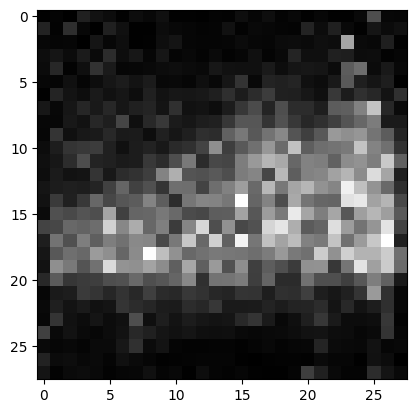

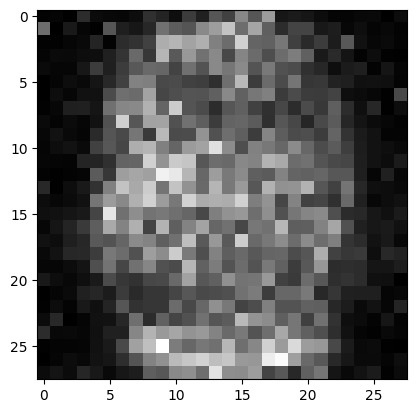

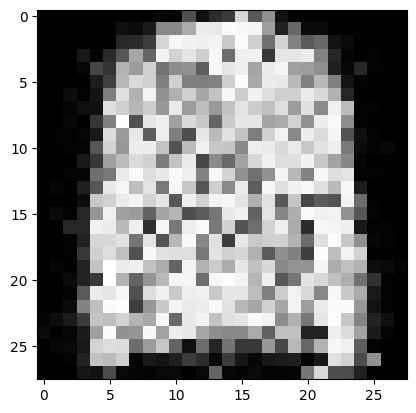

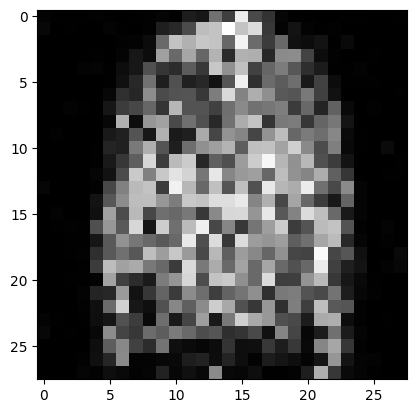

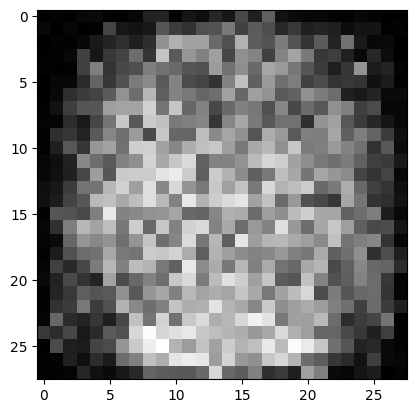

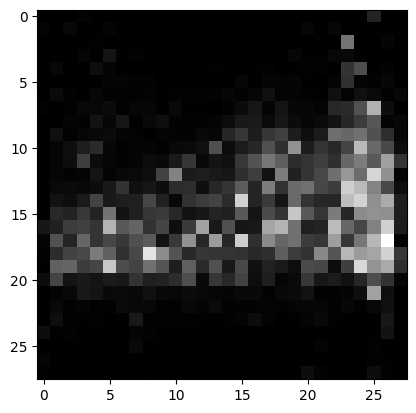

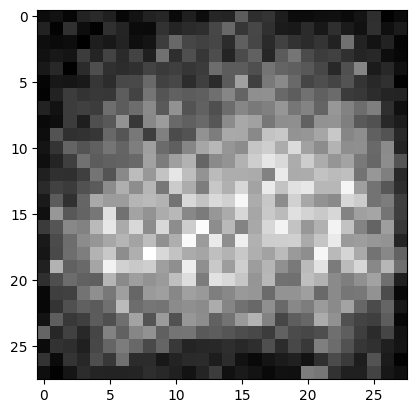

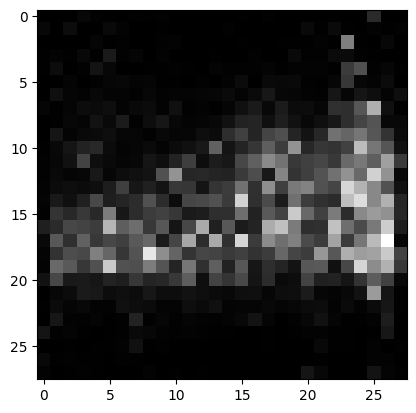

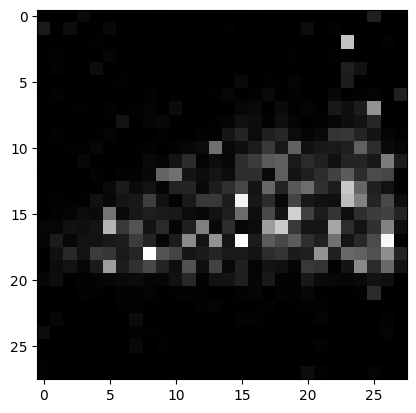

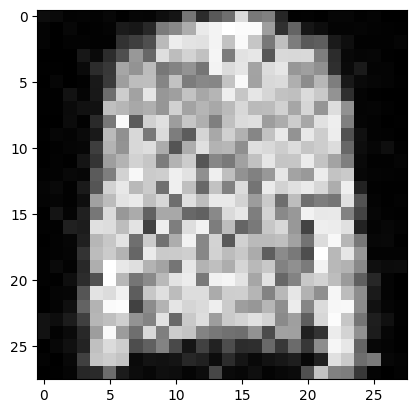

In [ ]:
z = torch.randn(BATCH_SIZE, 64).to(DEVICE) # 16개의 랜덤 잠재 벡터 생성
fake_images = G(z)
for i in range(10):
    fake_images_img = np.reshape(fake_images.data.cpu().numpy()[i],(28, 28))
    plt.imshow(fake_images_img, cmap = 'gray')
    plt.show()

## 저장한 모델 불러와서 결과물 표시하기

학습된 가중치 파일을 다시 읽어와 새 생성자 모델 `G_loaded`에 적용한 뒤, 무작위 잠재 벡터로 이미지를 생성해 격자 형태로 표시합니다.

생성자 가중치 로드 완료: ./checkpoints/gan_generator.pth


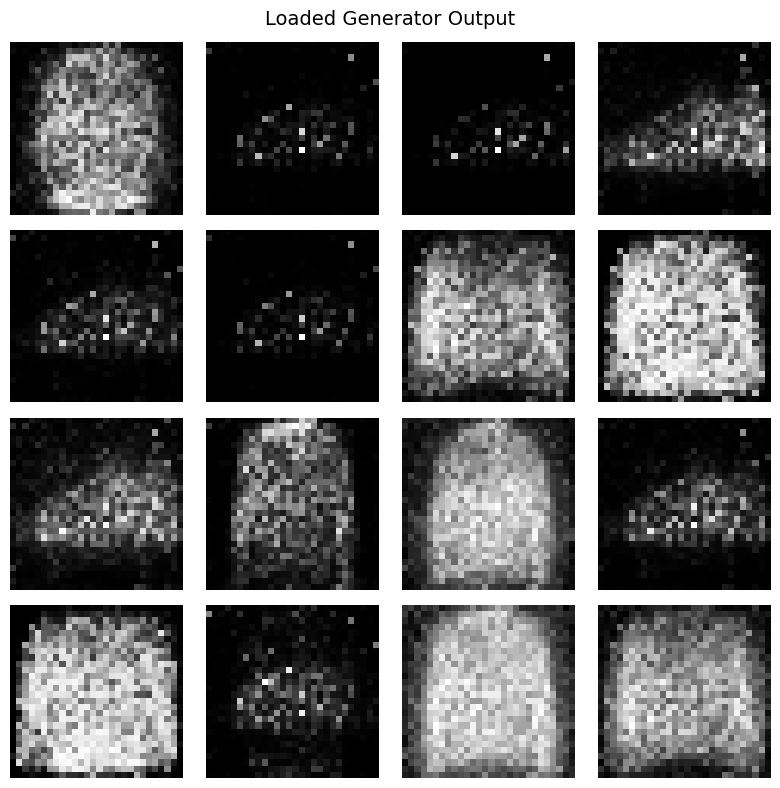

In [ ]:
# 동일한 구조의 새 생성자 정의
G_loaded = nn.Sequential(
    nn.Linear(64, 256),
    nn.ReLU(),
    nn.Linear(256, 256),
    nn.ReLU(),
    nn.Linear(256, 784),
    nn.Tanh()).to(DEVICE)

# 저장된 가중치 로드
G_loaded.load_state_dict(torch.load(G_PATH, map_location=DEVICE)) # 안전하게 가중치만 불러오기
G_loaded.eval()  # 추론 모드
print(f"생성자 가중치 로드 완료: {G_PATH}") # 로드 완료 메시지 출력

# 잠재 벡터 → 이미지 생성
N_SAMPLES = 16 # 생성할 샘플 이미지 개수 지정
with torch.no_grad(): # 추론 과정이므로 그래디언트 계산 비활성화로 메모리 절약
    z = torch.randn(N_SAMPLES, 64).to(DEVICE) # 16개의 랜덤 잠재 벡터 생성
    fake_images = G_loaded(z).cpu().numpy() # 이미지 생성 후 CPU로 넘겨 넘파이 배열로 변환

# 4x4 격자로 표시
fig, axes = plt.subplots(4, 4, figsize=(8, 8)) # 4행 4열 구성의 그래프 영역 생성
for i, ax in enumerate(axes.flatten()): # 격자 축을 순회하며 반복 처리
    img = fake_images[i].reshape(28, 28) # 1D 데이터를 28x28 이미지로 시각화
    ax.imshow(img, cmap='gray')
    ax.axis('off') # 불필요한 눈금선 숨기기
plt.suptitle('Loaded Generator Output', fontsize=14)
plt.tight_layout()
plt.show() # 완성된 격자 이미지 화면에 출력